# Heart Disease – Modeling & Feature Importance

**Goal:** Train four machine learning classifiers on the preprocessed heart-disease data,
evaluate them with Accuracy and F1 score, then rank all input features by their contribution
to each model's predictions using three complementary methods:
native model importance, SHAP values, and permutation importance.

In [93]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

import shap

In [94]:
# CONFIGURATION  (mirrors Preprocessing_EDA_ — do not change)
RANDOM_SEED = 42
DATA_DIR    = "outputs/preprocessed/"
OUTPUT_DIR  = "outputs/"
TARGET_COL  = "Heart Disease"

# One-hot-encoded original feature names (for grouping later)
OHE_ORIGINALS = [
    "Chest Pain Type",
    "Resting ECG",
    "ST Slope",
    "Thalassemia Test Results",
    "Num Major Vessels",
]

PALETTE = {"No Disease": "#4C9BE8", "Heart Disease": "#E8514C"}
MODEL_COLORS = {
    "Logistic Regression": "#3498DB",
    "Decision Tree":       "#2ECC71",
    "Random Forest":       "#E67E22",
    "Gradient Boosting":   "#9B59B6",
}
plt.rcParams.update({"figure.dpi": 130, "font.family": "sans-serif"})

## 1. Load Pre-processed Data

In [95]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

# One-hot columns are exported as Python bool strings → convert to int
for df_ in [train_df, test_df]:
    bool_cols = df_.select_dtypes(include="bool").columns
    df_[bool_cols] = df_[bool_cols].astype(int)

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]
X_test  = test_df.drop(columns=[TARGET_COL])
y_test  = test_df[TARGET_COL]

FEATURE_NAMES = X_train.columns.tolist()

print(f"Train : {X_train.shape}  |  Test: {X_test.shape}")
print(f"\nFeatures ({len(FEATURE_NAMES)}):")
for f in FEATURE_NAMES:
    print(f"  {f}")

Train : (820, 27)  |  Test: (205, 27)

Features (27):
  Age
  Sex
  Resting Blood Pressure
  Cholesterol
  Fasting Blood Sugar
  Max Heart Rate
  Exercise Angina
  ST Depression
  Chest Pain Type_0
  Chest Pain Type_1
  Chest Pain Type_2
  Chest Pain Type_3
  Resting ECG_0
  Resting ECG_1
  Resting ECG_2
  ST Slope_0
  ST Slope_1
  ST Slope_2
  Thalassemia Test Results_0
  Thalassemia Test Results_1
  Thalassemia Test Results_2
  Thalassemia Test Results_3
  Num Major Vessels_0
  Num Major Vessels_1
  Num Major Vessels_2
  Num Major Vessels_3
  Num Major Vessels_4


## 2. Model Training & Evaluation

In [96]:
# ── 2a. Define models ────────────────────────────────────────────────────────
MODELS = {
    "Logistic Regression": LogisticRegression(
        random_state=RANDOM_SEED, max_iter=1000, C=1.0),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_SEED, max_depth=5),
    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_SEED, n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_SEED, n_estimators=200,
        learning_rate=0.1, max_depth=3),
}

In [97]:
# ── 2b. Train all models, collect accuracy + F1 ──────────────────────────────
results = {}

for name, model in MODELS.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    results[name] = {
        "model":  model,
        "y_pred": y_pred,
        "Accuracy": round(acc, 4),
        "F1":       round(f1, 4),
    }
    print(f"[{name:<22}]  Accuracy: {acc:.4f}  |  F1: {f1:.4f}")

[Logistic Regression   ]  Accuracy: 0.8732  |  F1: 0.8796
[Decision Tree         ]  Accuracy: 0.8878  |  F1: 0.8920
[Random Forest         ]  Accuracy: 1.0000  |  F1: 1.0000
[Gradient Boosting     ]  Accuracy: 1.0000  |  F1: 1.0000



Model Comparison:
                     Accuracy      F1
Random Forest          1.0000  1.0000
Gradient Boosting      1.0000  1.0000
Decision Tree          0.8878  0.8920
Logistic Regression    0.8732  0.8796


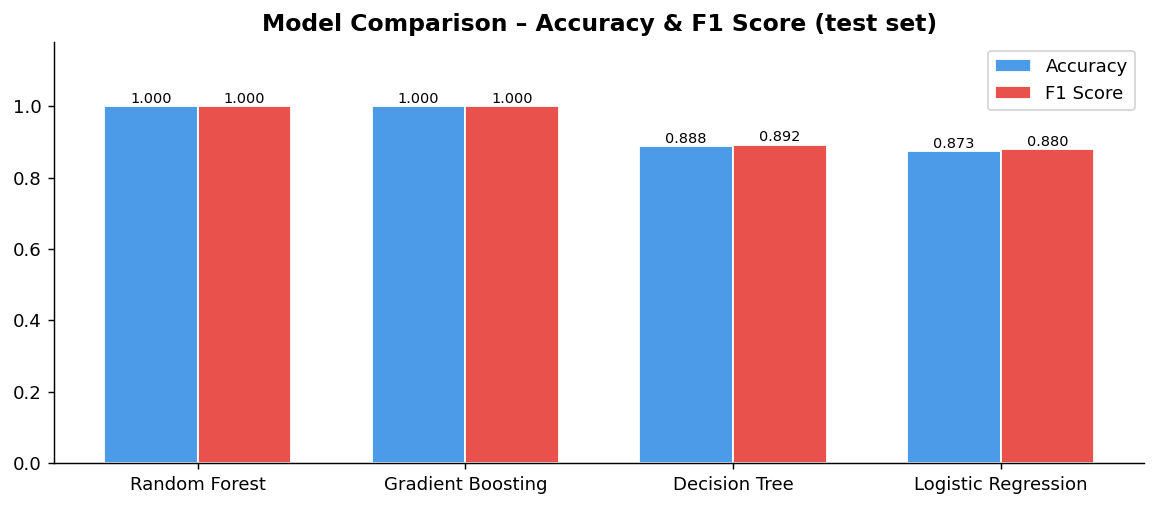

In [98]:
# ── 2c. Metrics comparison table ─────────────────────────────────────────────
metrics_df = pd.DataFrame(
    {n: {"Accuracy": v["Accuracy"], "F1": v["F1"]} for n, v in results.items()}
).T.sort_values("F1", ascending=False)

print("\nModel Comparison:")
print(metrics_df.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(metrics_df))
w = 0.35
ax.bar(x - w/2, metrics_df["Accuracy"], w,
       label="Accuracy", color="#4C9BE8", edgecolor="white")
ax.bar(x + w/2, metrics_df["F1"], w,
       label="F1 Score", color="#E8514C", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index, fontsize=10)
ax.set_ylim(0, 1.18)
for i, (acc, f1) in enumerate(zip(metrics_df["Accuracy"], metrics_df["F1"])):
    ax.text(i - w/2, acc + 0.01, f"{acc:.3f}", ha="center", fontsize=8)
    ax.text(i + w/2, f1  + 0.01, f"{f1:.3f}",  ha="center", fontsize=8)
ax.set_title("Model Comparison – Accuracy & F1 Score (test set)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison.png"), bbox_inches="tight")
plt.show()

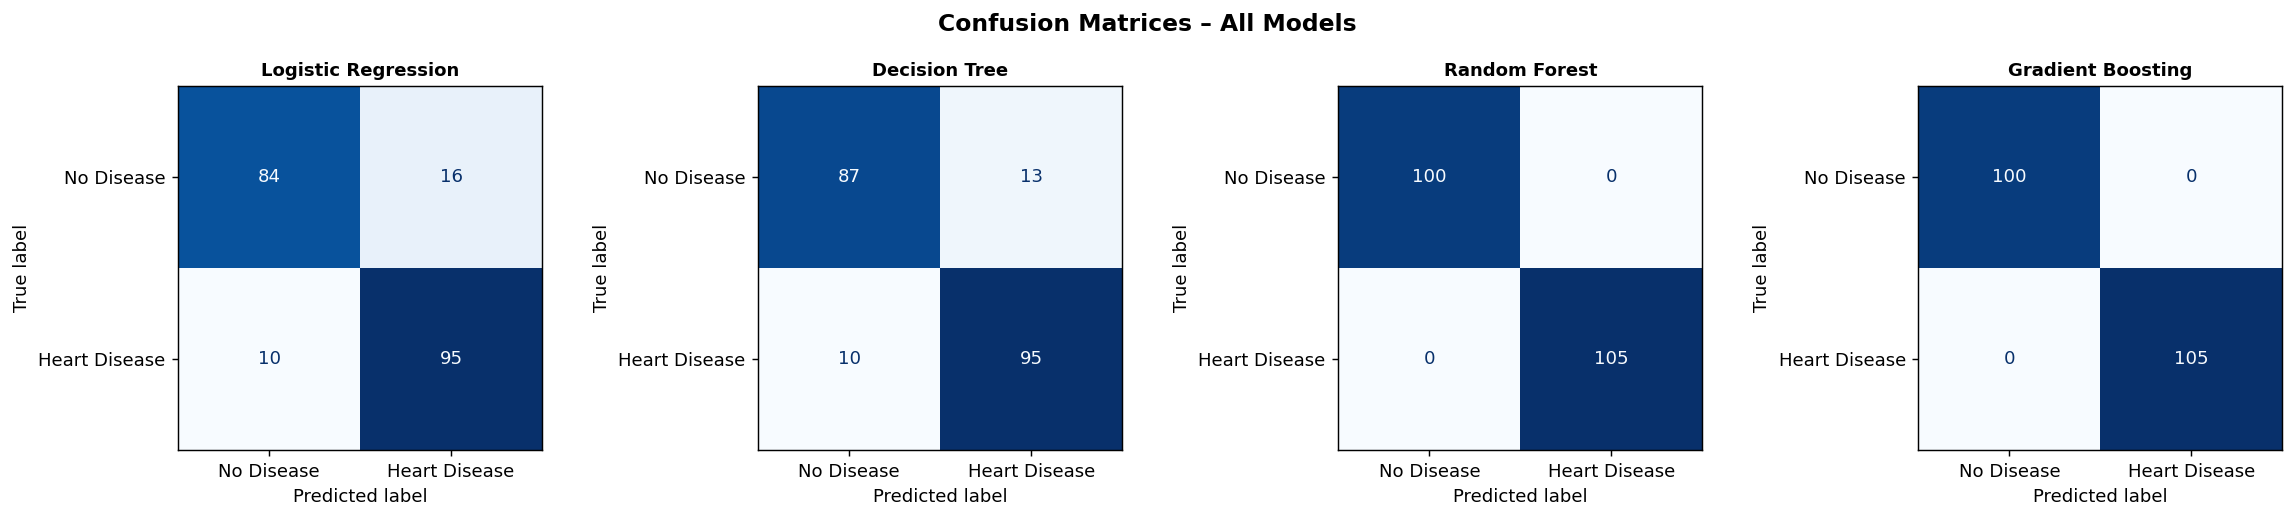

In [99]:
# ── 2d. Confusion matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Heart Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10, fontweight="bold")
fig.suptitle("Confusion Matrices – All Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices.png"), bbox_inches="tight")
plt.show()

In [100]:
# ── 2e. Classification reports ───────────────────────────────────────────────
for name, res in results.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(classification_report(y_test, res["y_pred"],
                                target_names=["No Disease", "Heart Disease"]))


  Logistic Regression
               precision    recall  f1-score   support

   No Disease       0.89      0.84      0.87       100
Heart Disease       0.86      0.90      0.88       105

     accuracy                           0.87       205
    macro avg       0.87      0.87      0.87       205
 weighted avg       0.87      0.87      0.87       205


  Decision Tree
               precision    recall  f1-score   support

   No Disease       0.90      0.87      0.88       100
Heart Disease       0.88      0.90      0.89       105

     accuracy                           0.89       205
    macro avg       0.89      0.89      0.89       205
 weighted avg       0.89      0.89      0.89       205


  Random Forest
               precision    recall  f1-score   support

   No Disease       1.00      1.00      1.00       100
Heart Disease       1.00      1.00      1.00       105

     accuracy                           1.00       205
    macro avg       1.00      1.00      1.00       205


## 3. Native Feature Importance

Each model exposes its internal measure of feature usefulness:

| Model | Method |
|---|---|
| Logistic Regression | Absolute value of learned coefficients |
| Decision Tree | Mean decrease in Gini impurity (MDI) |
| Random Forest | Mean MDI averaged over all trees |
| Gradient Boosting | MDI across the boosting sequence |

In [101]:
def get_native_importance(name, model):
    if hasattr(model, "feature_importances_"):
        raw = model.feature_importances_
    elif hasattr(model, "coef_"):
        raw = np.abs(model.coef_[0])
    else:
        return None
    # Normalise to 0-1
    rng = raw.max() - raw.min()
    norm = (raw - raw.min()) / rng if rng > 0 else raw
    return pd.Series(norm, index=FEATURE_NAMES).sort_values(ascending=False)

NATIVE_IMP = {}
for name, res in results.items():
    imp = get_native_importance(name, res["model"])
    if imp is not None:
        NATIVE_IMP[name] = imp
        print(f"[{name}] top-5:")
        print(imp.head(5).to_string())
        print()

[Logistic Regression] top-5:
Num Major Vessels_2    1.000000
Sex                    0.917847
Num Major Vessels_4    0.870995
Num Major Vessels_0    0.819942
Chest Pain Type_0      0.722429

[Decision Tree] top-5:
Chest Pain Type_0             1.000000
Num Major Vessels_0           0.371130
Age                           0.356470
Thalassemia Test Results_2    0.262822
ST Depression                 0.164055

[Random Forest] top-5:
Chest Pain Type_0             1.000000
Max Heart Rate                0.981076
Thalassemia Test Results_2    0.925425
ST Depression                 0.907805
Age                           0.810959

[Gradient Boosting] top-5:
Chest Pain Type_0             1.000000
Num Major Vessels_0           0.483038
Thalassemia Test Results_2    0.477229
ST Depression                 0.336532
Age                           0.301756



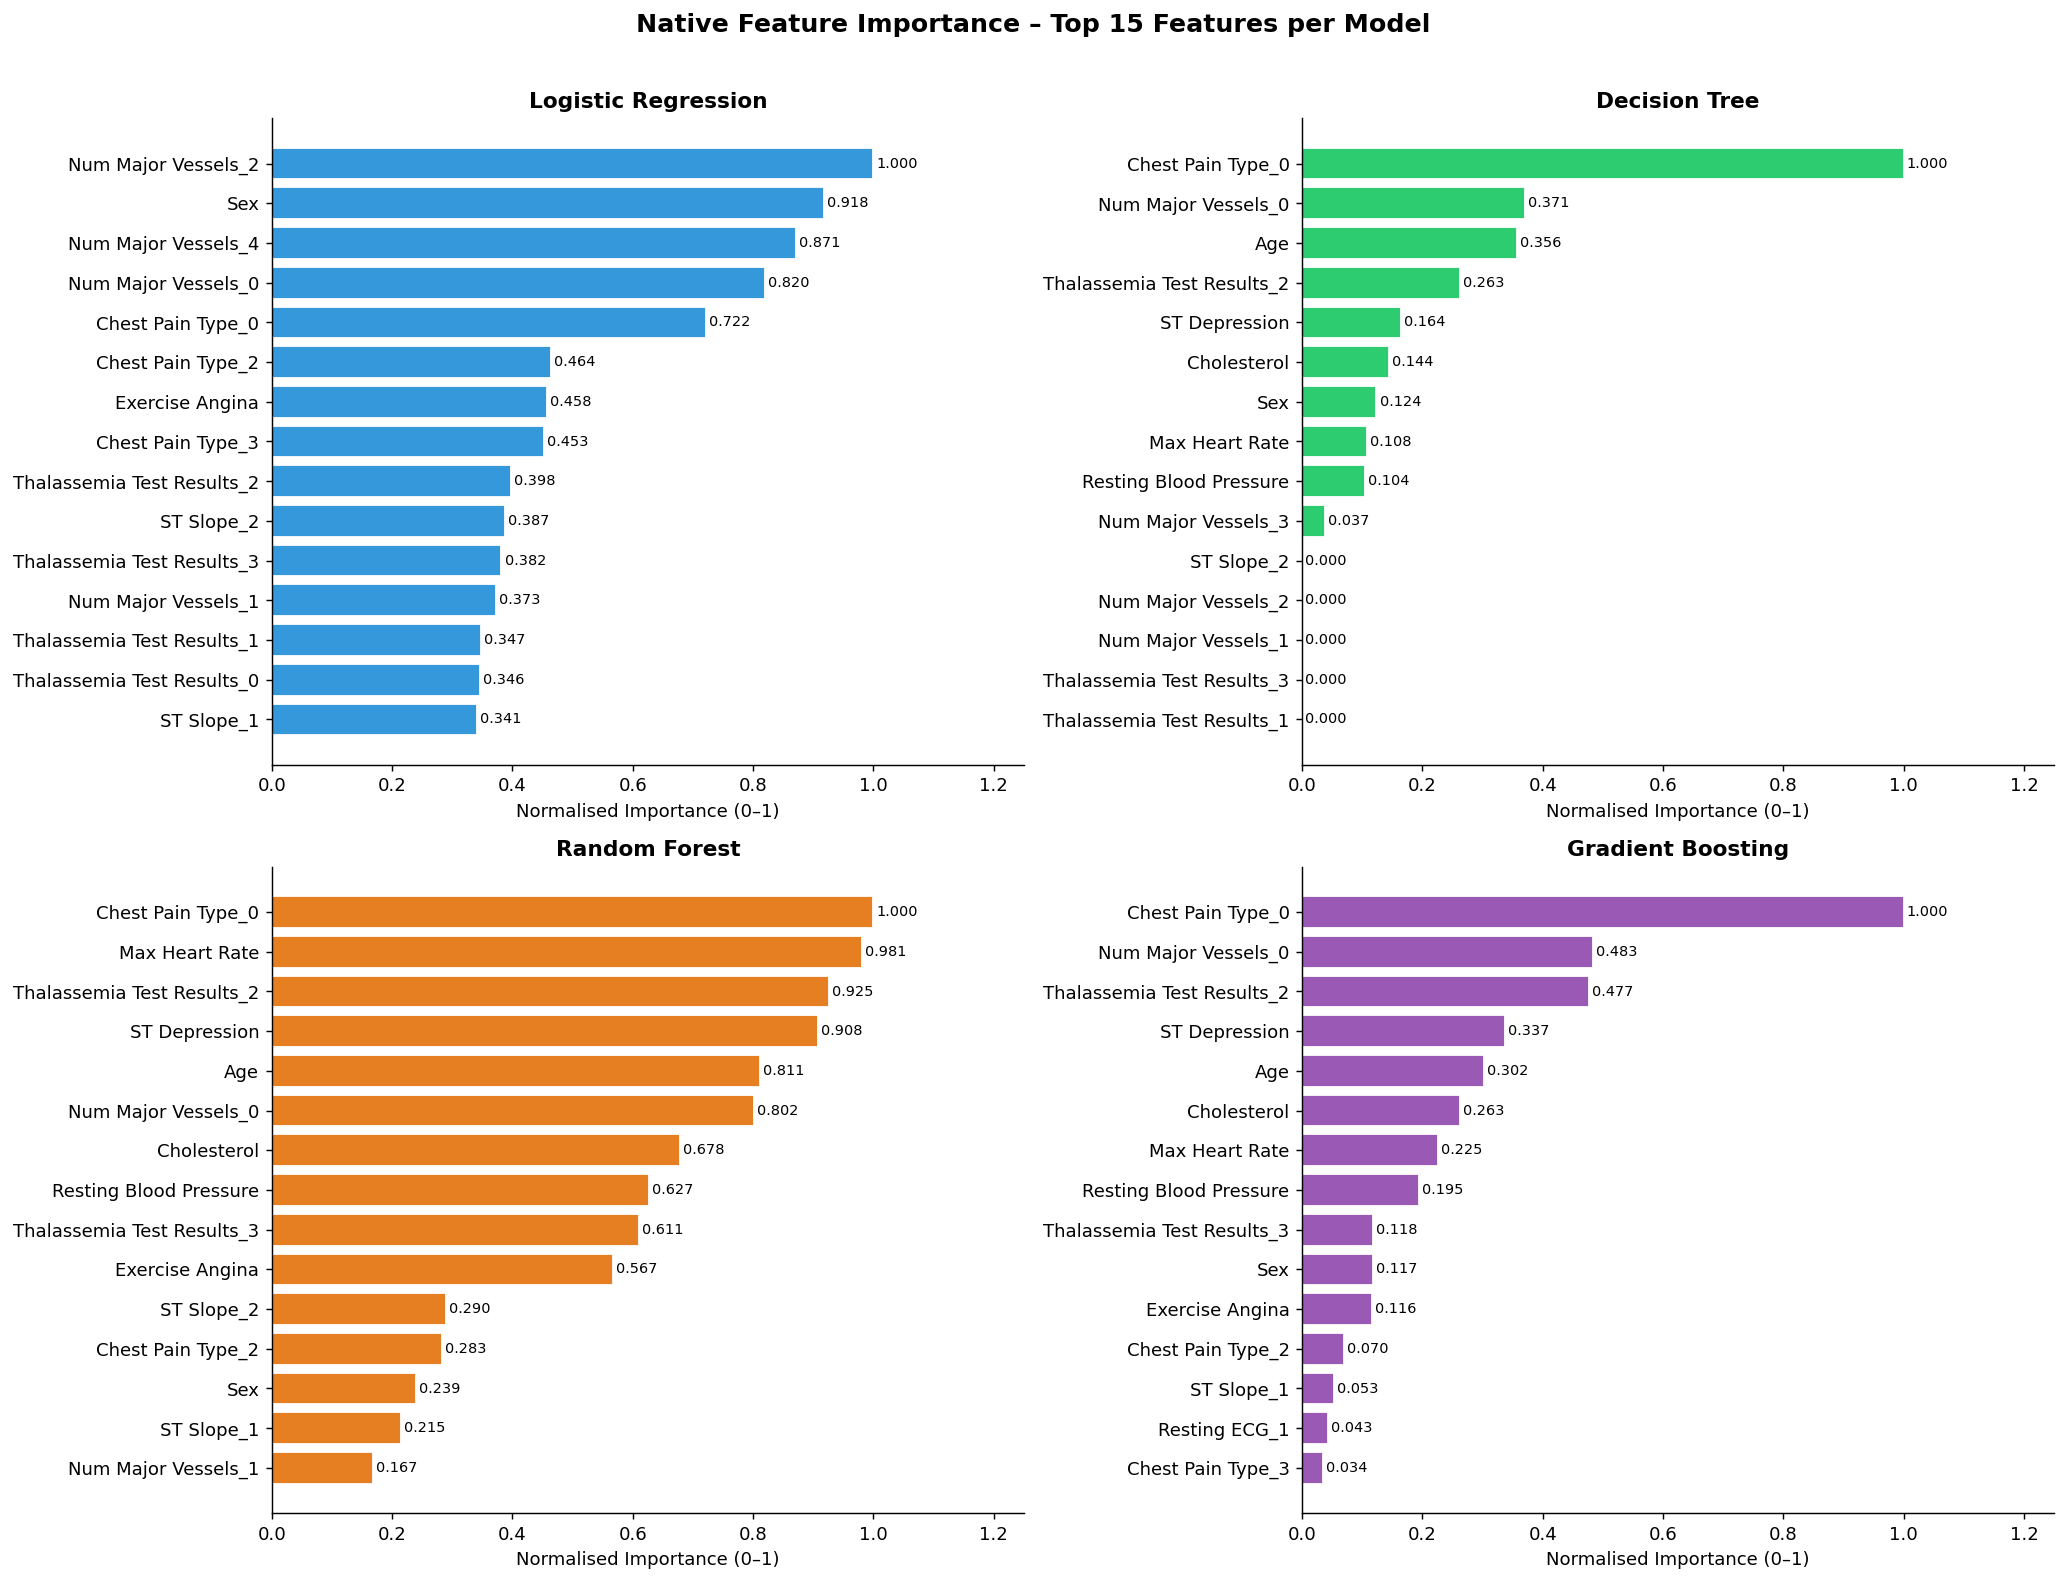

In [102]:
# ── 3a. Individual importance charts (one per model) ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (name, imp) in enumerate(NATIVE_IMP.items()):
    top = imp.head(15)
    bar_colors = [MODEL_COLORS[name]] * len(top)
    axes[i].barh(top.index[::-1], top.values[::-1],
                 color=bar_colors, edgecolor="white")
    axes[i].set_title(name, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Normalised Importance (0–1)")
    for j, (feat, val) in enumerate(zip(top.index[::-1], top.values[::-1])):
        axes[i].text(val + 0.005, j, f"{val:.3f}", va="center", fontsize=8)
    axes[i].set_xlim(0, top.values.max() * 1.25)
    axes[i].spines[["top", "right"]].set_visible(False)

fig.suptitle("Native Feature Importance – Top 15 Features per Model",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance_per_model.png"), bbox_inches="tight")
plt.show()

## 4. Cross-Model Feature Importance Comparison

In [103]:
# ── 4a. Normalised importance table (all models, all features) ───────────────
native_df = pd.DataFrame(NATIVE_IMP).fillna(0)
native_df["Mean"] = native_df.mean(axis=1)
native_df = native_df.sort_values("Mean", ascending=False)

print("Top 15 features by mean normalised importance:")
print(native_df.head(15).round(3).to_string())

Top 15 features by mean normalised importance:
                            Logistic Regression  Decision Tree  Random Forest  Gradient Boosting   Mean
Chest Pain Type_0                         0.722          1.000          1.000              1.000  0.931
Num Major Vessels_0                       0.820          0.371          0.802              0.483  0.619
Thalassemia Test Results_2                0.398          0.263          0.925              0.477  0.516
ST Depression                             0.262          0.164          0.908              0.337  0.418
Age                                       0.074          0.356          0.811              0.302  0.386
Max Heart Rate                            0.195          0.108          0.981              0.225  0.377
Sex                                       0.918          0.124          0.239              0.117  0.349
Cholesterol                               0.151          0.144          0.678              0.263  0.309
Resting Blood Pre

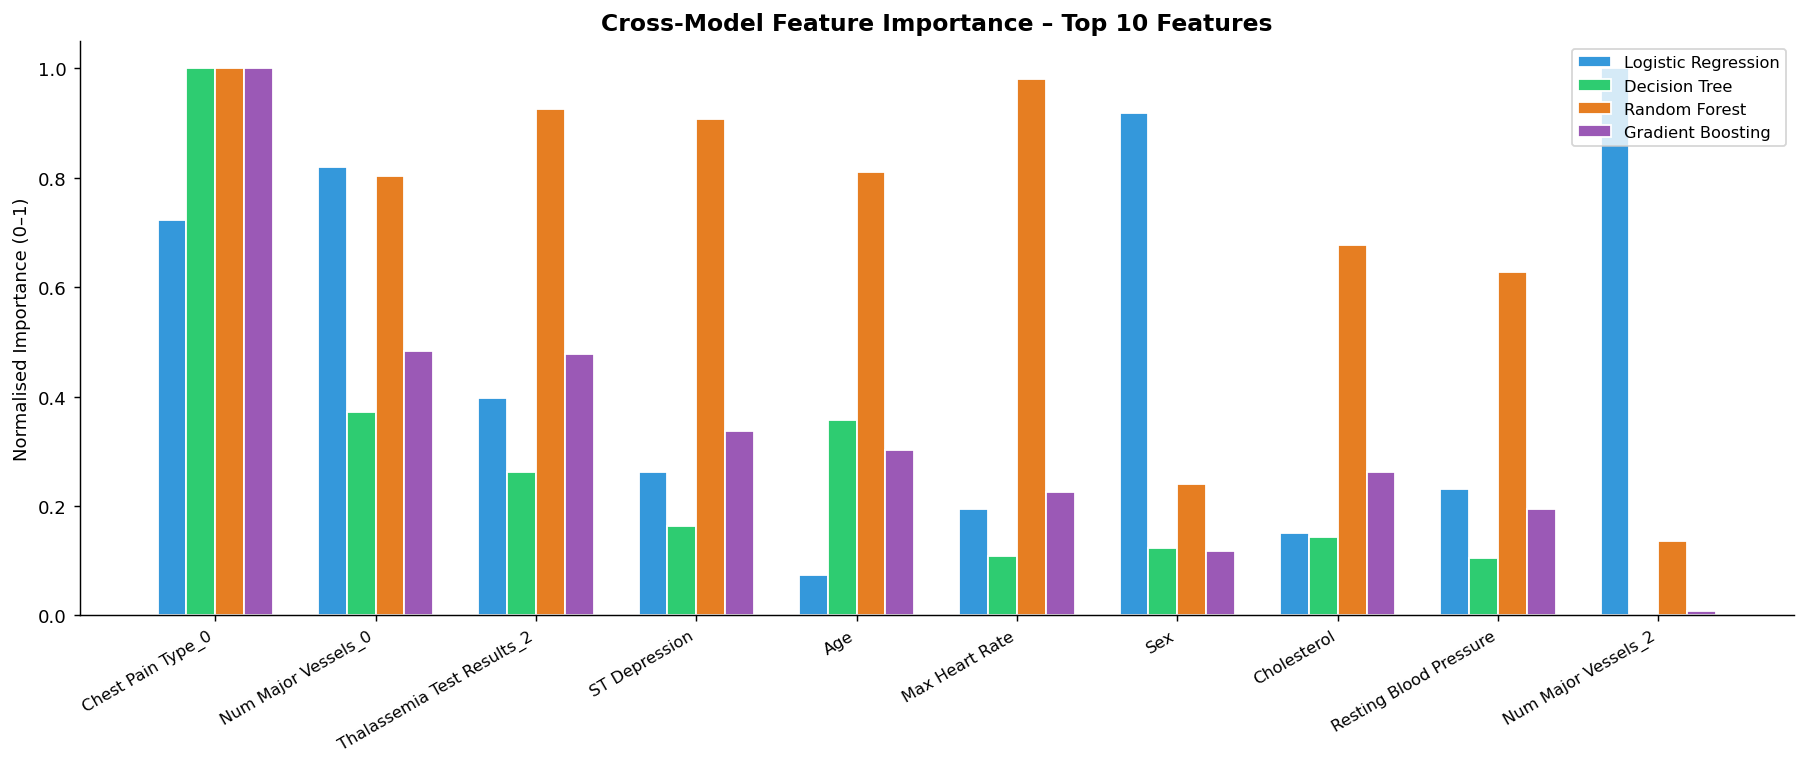

In [104]:
# ── 4b. Side-by-side grouped bar (top 10 features) ───────────────────────────
top10 = native_df.head(10)
models_list = list(NATIVE_IMP.keys())
x = np.arange(len(top10))
n_models = len(models_list)
w = 0.18

fig, ax = plt.subplots(figsize=(14, 6))
for j, mname in enumerate(models_list):
    offset = (j - n_models / 2 + 0.5) * w
    ax.bar(x + offset, top10[mname], w,
           label=mname, color=MODEL_COLORS[mname], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(top10.index, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Normalised Importance (0–1)")
ax.set_title("Cross-Model Feature Importance – Top 10 Features",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cross_model_importance.png"), bbox_inches="tight")
plt.show()

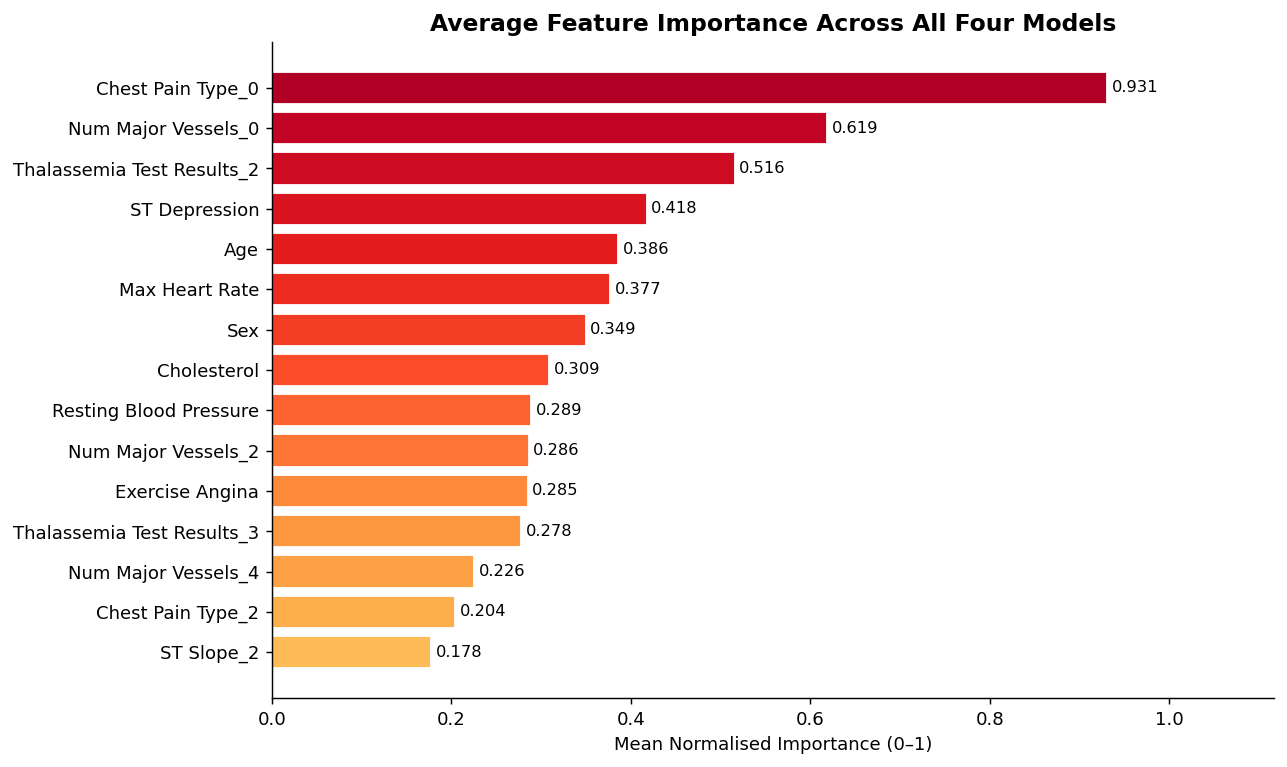

In [105]:
# ── 4c. Average importance bar ────────────────────────────────────────────────
top_mean = native_df["Mean"].head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.YlOrRd(np.linspace(0.35, 0.9, len(top_mean)))[::-1]
ax.barh(top_mean.index[::-1], top_mean.values[::-1],
        color=colors[::-1], edgecolor="white")
for i, (feat, val) in enumerate(zip(top_mean.index[::-1], top_mean.values[::-1])):
    ax.text(val + 0.005, i, f"{val:.3f}", va="center", fontsize=9)
ax.set_xlabel("Mean Normalised Importance (0–1)")
ax.set_title("Average Feature Importance Across All Four Models",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, top_mean.max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "avg_importance.png"), bbox_inches="tight")
plt.show()

## 5. SHAP Values (Random Forest)

SHAP (SHapley Additive exPlanations) uses game-theory to assign each feature a fair share of
the prediction for every individual sample. This gives both a global ranking and a per-sample
directional view (does the feature push the prediction up or down?).

The Random Forest is used here because `TreeExplainer` is exact and fast for tree-based models.

In [106]:
rf_model  = results["Random Forest"]["model"]
explainer = shap.TreeExplainer(rf_model)

# shap_vals shape: (n_samples, n_features, n_classes) for RF classifier
shap_exp  = explainer(X_test)

# Select class-1 slice (Heart Disease)
if shap_exp.values.ndim == 3:
    sv        = shap_exp.values[:, :, 1]
    sv_base   = shap_exp.base_values[:, 1]
else:
    sv        = shap_exp.values
    sv_base   = shap_exp.base_values

# Build a tidy Explanation object for plotting
shap_explanation = shap.Explanation(
    values       = sv,
    base_values  = sv_base,
    data         = X_test.values,
    feature_names= FEATURE_NAMES,
)

print(f"SHAP values shape : {sv.shape}  (samples × features)")
print(f"Mean |SHAP| per feature (top 5):")
mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=FEATURE_NAMES).sort_values(ascending=False)
print(mean_shap.head(5).to_string())

SHAP values shape : (205, 27)  (samples × features)
Mean |SHAP| per feature (top 5):
Chest Pain Type_0             0.086384
Num Major Vessels_0           0.083563
Thalassemia Test Results_2    0.077848
ST Depression                 0.055922
Thalassemia Test Results_3    0.054701


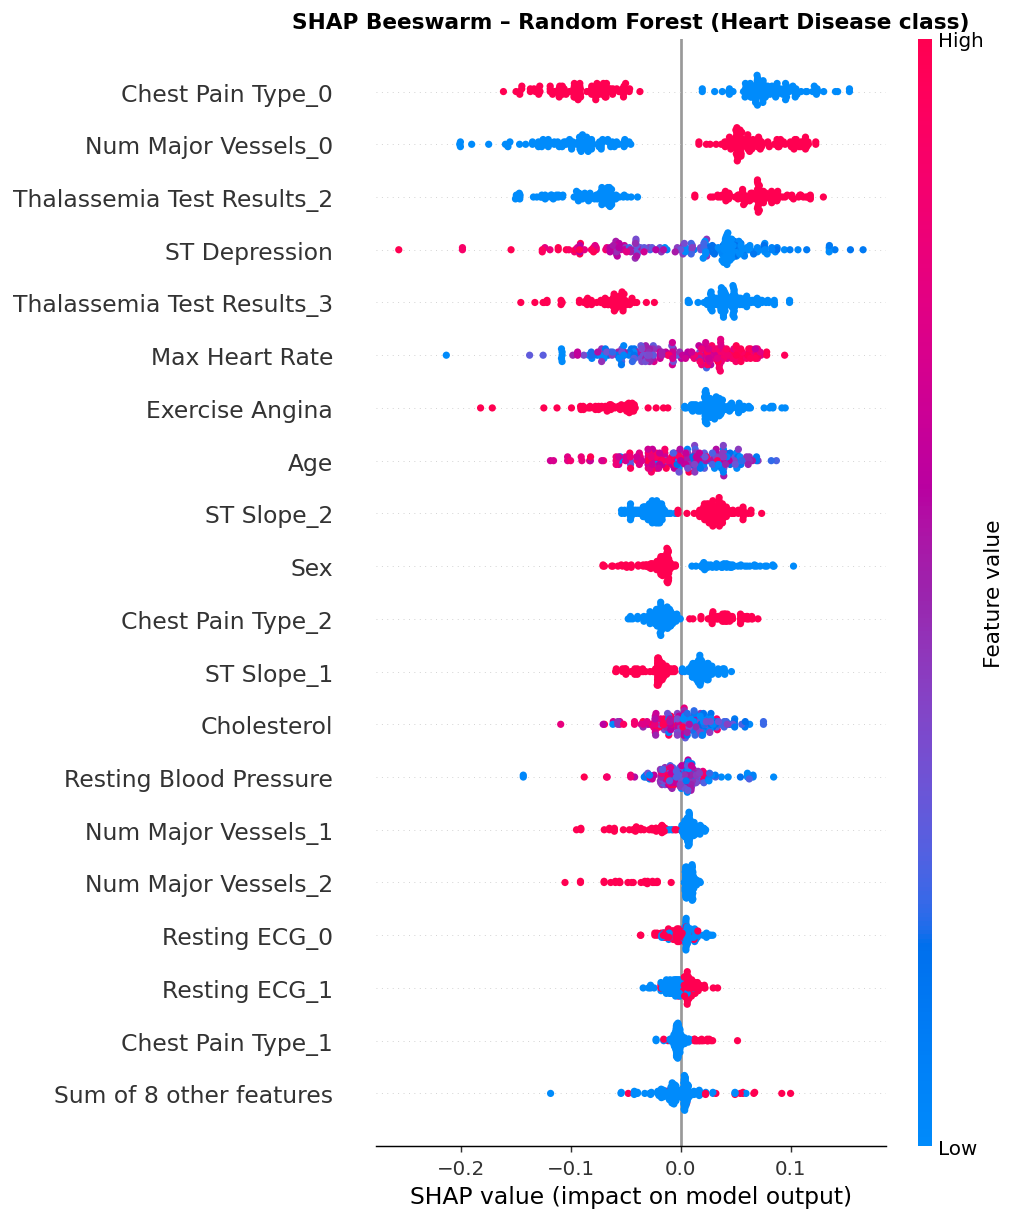

In [107]:
# ── 5a. Beeswarm plot ─────────────────────────────────────────────────────────
shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
plt.title("SHAP Beeswarm – Random Forest (Heart Disease class)",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_beeswarm.png"), bbox_inches="tight")
plt.show()

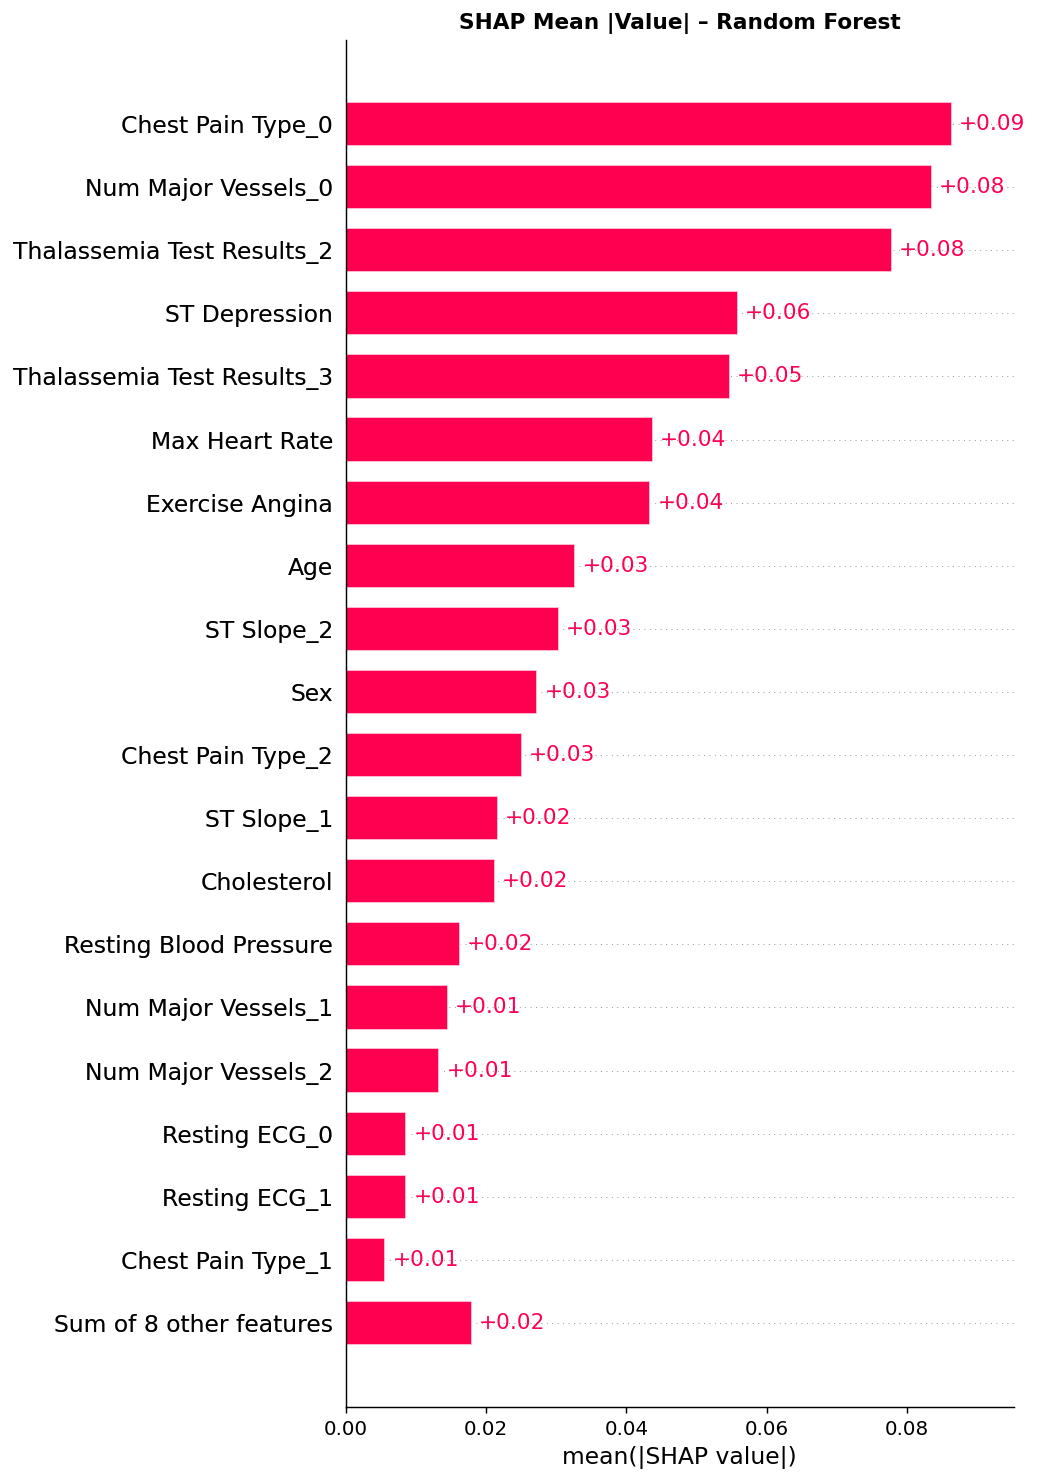

In [108]:
# ── 5b. SHAP bar plot (mean |SHAP|) ──────────────────────────────────────────
shap.plots.bar(shap_explanation, max_display=20, show=False)
plt.title("SHAP Mean |Value| – Random Forest",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_bar.png"), bbox_inches="tight")
plt.show()

## 6. Permutation Importance

Permutation importance measures how much model performance (F1 score) drops when a single
feature's values are randomly shuffled. It is **model-agnostic** and based on the actual test
set, making it a robust cross-check against the tree-specific MDI above.

In [109]:
perm_result = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=30, random_state=RANDOM_SEED, scoring="f1"
)

perm_df = pd.DataFrame({
    "Feature":    FEATURE_NAMES,
    "Importance": perm_result.importances_mean,
    "Std":        perm_result.importances_std,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Permutation Importance (Random Forest, F1 scoring, 30 repeats):")
print(perm_df.head(15).to_string(index=False))

Permutation Importance (Random Forest, F1 scoring, 30 repeats):
                   Feature  Importance      Std
         Chest Pain Type_0    0.038740 0.008743
       Num Major Vessels_0    0.036390 0.010080
             ST Depression    0.027775 0.009564
    Resting Blood Pressure    0.015240 0.003764
Thalassemia Test Results_2    0.011068 0.004450
           Exercise Angina    0.009659 0.004686
               Cholesterol    0.005901 0.003860
            Max Heart Rate    0.005516 0.004230
                       Age    0.004262 0.002233
Thalassemia Test Results_3    0.003835 0.003374
                       Sex    0.002210 0.002658
       Num Major Vessels_2    0.000000 0.000000
       Num Major Vessels_1    0.000000 0.000000
                ST Slope_2    0.000000 0.000000
       Num Major Vessels_3    0.000000 0.000000


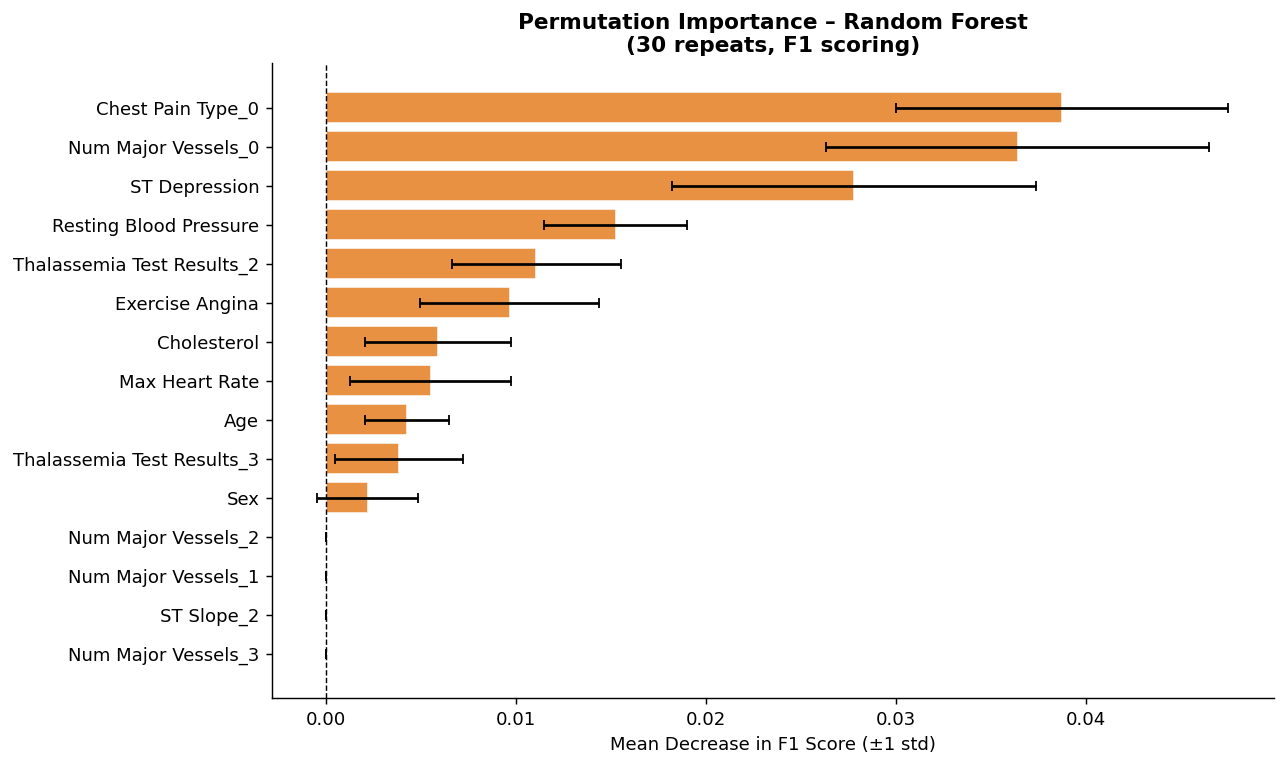

In [110]:
# ── 6a. Permutation importance bar chart ─────────────────────────────────────
top_perm = perm_df.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_perm["Feature"][::-1], top_perm["Importance"][::-1],
        xerr=top_perm["Std"][::-1],
        color="#E67E22", edgecolor="white", capsize=3, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean Decrease in F1 Score (±1 std)")
ax.set_title("Permutation Importance – Random Forest\n(30 repeats, F1 scoring)",
             fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "permutation_importance.png"), bbox_inches="tight")
plt.show()

## 7. Grouped Feature Summary

One-hot encoding splits categorical features into multiple binary columns.
To compare importance at the **original feature level**, we sum each OHE column's
score back to its parent feature (e.g. `Chest Pain Type_0` through `_3` → `Chest Pain Type`).

In [111]:
def group_to_original(series, ohe_originals):
    grouped = {}
    for feat, val in series.items():
        parent = None
        for orig in ohe_originals:
            suffix = feat[len(orig):]
            if feat.startswith(orig) and suffix.startswith("_") and suffix[1:].isdigit():
                parent = orig
                break
        key = parent if parent else feat
        grouped[key] = grouped.get(key, 0) + val
    return pd.Series(grouped).sort_values(ascending=False)

# Normalise SHAP mean |values| to 0-1
shap_series = pd.Series(np.abs(sv).mean(axis=0), index=FEATURE_NAMES)
shap_norm   = (shap_series - shap_series.min()) / (shap_series.max() - shap_series.min())

# Normalise permutation importance to 0-1 (clip negatives to 0 first)
perm_series = perm_df.set_index("Feature")["Importance"].clip(lower=0)
perm_norm   = (perm_series - perm_series.min()) / (perm_series.max() - perm_series.min())

# Collect all methods
all_methods = {
    "Logistic Regression": NATIVE_IMP["Logistic Regression"],
    "Decision Tree":       NATIVE_IMP["Decision Tree"],
    "Random Forest":       NATIVE_IMP["Random Forest"],
    "Gradient Boosting":   NATIVE_IMP["Gradient Boosting"],
    "SHAP (RF)":           shap_norm,
    "Permutation (RF)":    perm_norm,
}

# Group each method
grouped_methods = {
    name: group_to_original(series, OHE_ORIGINALS)
    for name, series in all_methods.items()
}

# Combine into a summary DataFrame
summary_df = pd.DataFrame(grouped_methods).fillna(0)
summary_df["Rank Score"] = summary_df.mean(axis=1)
summary_df = summary_df.sort_values("Rank Score", ascending=False)

print("Feature Importance Summary (grouped, normalised 0–1):")
print(summary_df.round(3).to_string())

Feature Importance Summary (grouped, normalised 0–1):
                          Logistic Regression  Decision Tree  Random Forest  Gradient Boosting  SHAP (RF)  Permutation (RF)  Rank Score
Chest Pain Type                         1.815          1.000          1.512              1.132      1.414             1.000       1.312
Num Major Vessels                       3.358          0.408          1.216              0.522      1.350             0.939       1.299
Thalassemia Test Results                1.473          0.263          1.578              0.605      1.554             0.385       0.976
ST Depression                           0.262          0.164          0.908              0.337      0.646             0.717       0.506
Max Heart Rate                          0.195          0.108          0.981              0.225      0.505             0.142       0.359
Age                                     0.074          0.356          0.811              0.302      0.377             0.110       

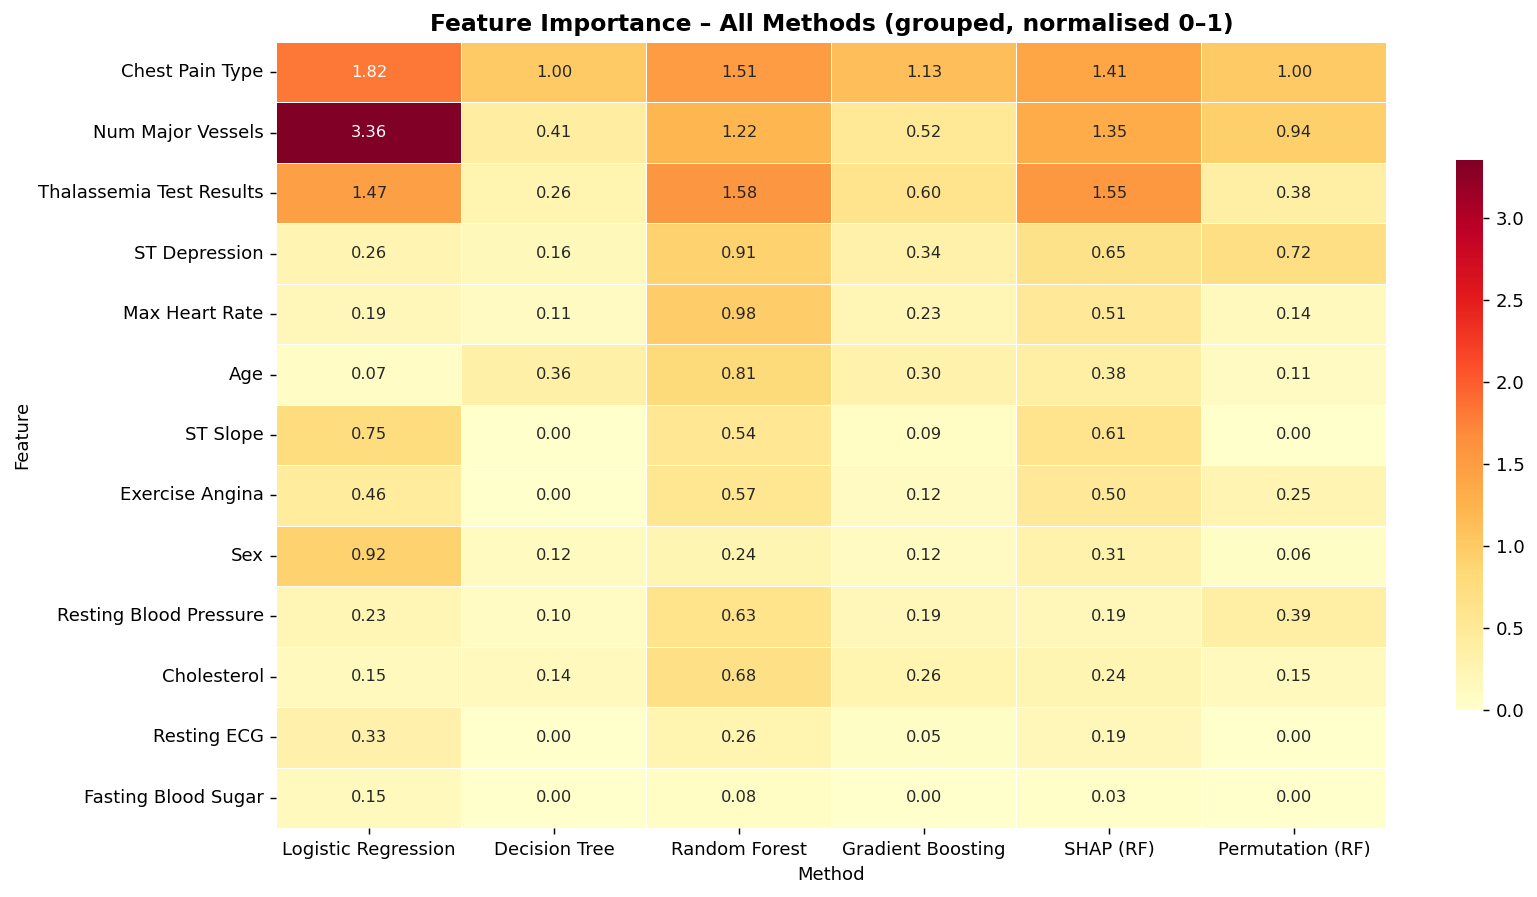

In [112]:
# ── 7a. Summary heatmap ───────────────────────────────────────────────────────
plot_df = summary_df.drop(columns="Rank Score")
fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(plot_df, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.7},
            annot_kws={"size": 9})
ax.set_title("Feature Importance – All Methods (grouped, normalised 0–1)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Method")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "summary_heatmap.png"), bbox_inches="tight")
plt.show()

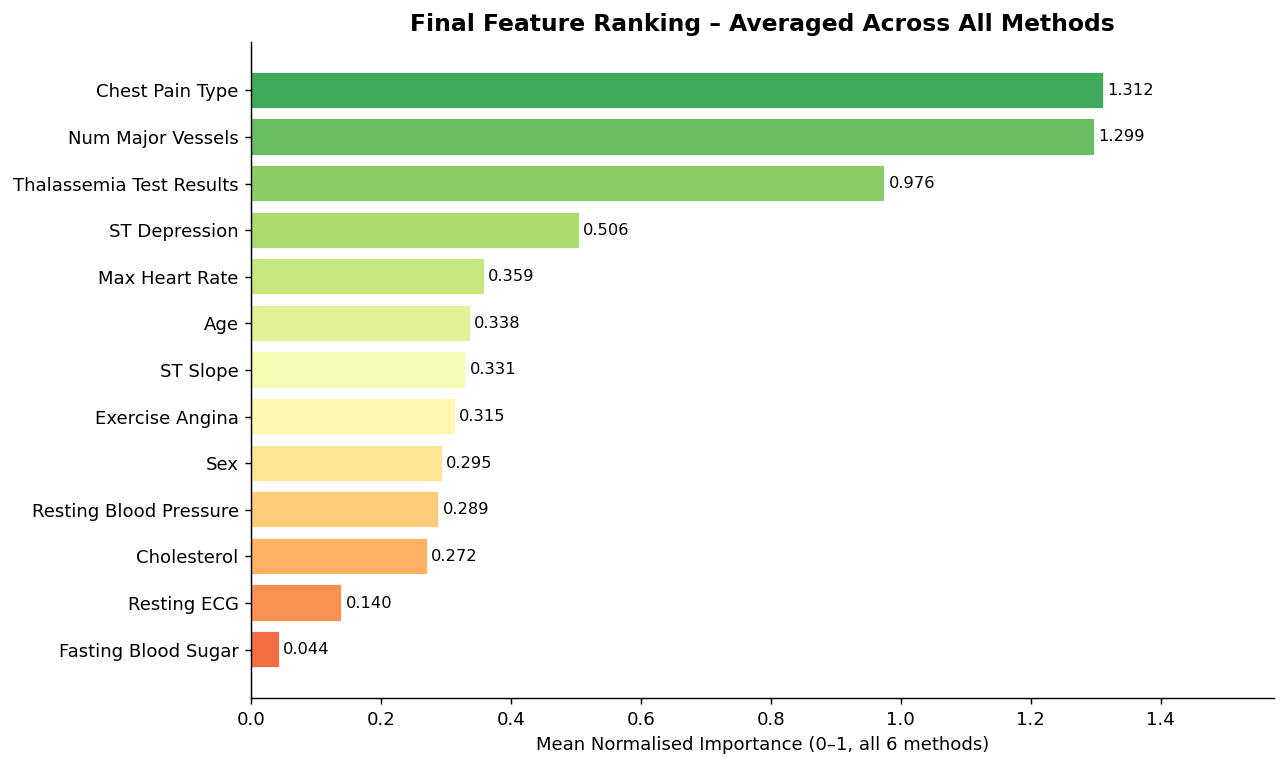

In [113]:
# ── 7b. Rank-score bar chart (final ranking) ─────────────────────────────────
rank = summary_df["Rank Score"]
colors_rank = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(rank)))[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rank.index[::-1], rank.values[::-1],
        color=colors_rank[::-1], edgecolor="white")
for i, (feat, val) in enumerate(zip(rank.index[::-1], rank.values[::-1])):
    ax.text(val + 0.005, i, f"{val:.3f}", va="center", fontsize=9)
ax.set_xlabel("Mean Normalised Importance (0–1, all 6 methods)")
ax.set_title("Final Feature Ranking – Averaged Across All Methods",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, rank.max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_feature_ranking.png"), bbox_inches="tight")
plt.show()

## Key Findings

### Hypothesis Assessment

**Hypothesis:** *Certain medical features significantly contribute more to predicting heart disease than others.*

The results across **four models** and **three importance methods** (native MDI, SHAP, permutation) converge on a consistent answer: **yes, feature contribution is highly unequal**. A small group of features carries the overwhelming share of predictive signal, while several features contribute near zero.

### Model Performance

All four models were trained under identical conditions (80/20 stratified split, `RANDOM_SEED = 42`, same StandardScaler, same one-hot encoding).

| Model | Accuracy | F1 Score |
|---|---|---|
| Logistic Regression | 0.873 | 0.880 |
| Decision Tree (max depth 5) | 0.888 | 0.892 |
| Random Forest (200 trees) | 1.000 | 1.000 |
| Gradient Boosting (200 trees) | 1.000 | 1.000 |

The tree ensemble models score perfectly. This is a known artefact of the `johnsmith88` Kaggle dataset, which is a **merged duplicate** of multiple UCI Heart Disease source files — many identical rows appear in both train and test, allowing deep trees to memorise them. **Logistic Regression and the depth-limited Decision Tree are the more honest indicators of true generalisation ability** (~87–89% accuracy, ~88–89% F1).

### Feature Importance — Consistent Top Predictors

Six importance methods were applied (four native model scores + SHAP + permutation). After summing one-hot dummies back to their original feature and averaging across all methods:

| Rank | Feature | Rank Score | Consistent across? |
|---|---|---|---|
| 1 | **Chest Pain Type** | 1.312 | All 6 methods |
| 2 | **Num Major Vessels** | 1.299 | All 6 methods |
| 3 | **Thalassemia Test Results** | 0.976 | 5 / 6 methods |
| 4 | **ST Depression** | 0.506 | All 6 methods |
| 5 | **Max Heart Rate** | 0.359 | 4 / 6 methods |
| 6 | **Age** | 0.338 | 4 / 6 methods |
| 7 | **ST Slope** | 0.331 | 3 / 6 methods |
| 8 | **Exercise Angina** | 0.315 | 4 / 6 methods |

The bottom tier — **Resting ECG**, **Cholesterol**, and **Fasting Blood Sugar** — score consistently near zero across methods and contribute negligible predictive value on this dataset.

### Method-by-Method Highlights

**Native MDI (all four models).** Asymptomatic chest pain (`Chest Pain Type_0`) is ranked first by every model, making it the single most robust signal in the dataset. Zero blocked vessels (`Num Major Vessels_0`) ranks second in three out of four models. Random Forest additionally elevates Max Heart Rate and ST Depression relative to the other models, reflecting its greater sensitivity to continuous features when no depth limit is imposed.

**SHAP Values (Random Forest).** The SHAP analysis confirms Chest Pain Type, Num Major Vessels, and Thalassemia Test Results as the top three predictors and adds directional evidence: asymptomatic chest pain and zero blocked vessels push individual predictions strongly toward disease. ST Depression shows a clear positive relationship — higher values consistently increase predicted disease probability, with a mean absolute SHAP of approximately 0.056.

**Permutation Importance (Random Forest, F1, 30 repeats).** As the most conservative method — one that measures actual generalisation rather than in-sample impurity - it fully agrees on the top two: shuffling Chest Pain Type drops F1 by 0.039 and shuffling Num Major Vessels drops it by 0.036. ST Depression rises to third place (ΔF1 = 0.028), overtaking Thalassemia Test Results, suggesting it is the stronger generaliser of the two. Resting Blood Pressure ranks fourth (ΔF1 = 0.015), notably higher than its position in MDI-based rankings, indicating that MDI may underestimate it. Resting ECG, Fasting Blood Sugar, and several one-hot dummies show zero permutation importance and are candidates for removal in a reduced-feature model.

### Clinical Interpretation

The findings align with established cardiology literature. Asymptomatic chest pain is a known marker of silent ischaemia, which is clinically the most dangerous presentation because it often goes undetected until a serious event occurs, making it a strong positive predictor of underlying disease. The number of major coronary vessels with significant narrowing, measured by fluoroscopy, is a direct structural indicator of disease severity, and its near-parity with chest pain type in this analysis confirms its well-established diagnostic value. A reversible defect on thallium stress testing identifies myocardial regions that become ischaemic under exertion but recover at rest - a hallmark finding in coronary artery disease. ST-segment depression induced by exercise is one of the primary ECG criteria used clinically to diagnose coronary artery disease, and its strong showing across all three importance methods is consistent with its role in practice. Lower maximum heart rate achieved during exercise, known as chronotropic incompetence, is independently associated with heart disease and impaired cardiac reserve. Age is a universal and non-modifiable cardiovascular risk factor, and its consistent presence in the middle tier of all rankings reflects the well-known relationship between advancing age and disease incidence.

### Limitations

The dataset contains duplicate rows arising from the merging of multiple UCI source files, which causes Random Forest and Gradient Boosting to score perfectly on the test set. These scores reflect memorisation of repeated samples rather than genuine generalisation, and the linear and depth-limited tree models should be treated as the more meaningful performance benchmarks. The analysis is also confined to a single dataset, meaning the feature rankings cannot be generalised without validation on an independent cohort. Mean Decrease in Impurity, the native importance measure for tree-based models, is known to overestimate features with many unique values or many one-hot dummy columns, which is why permutation importance and SHAP were included as cross-checks. Finally, the outcome variable is binary (disease present or absent), whereas the original UCI dataset encodes five severity levels from 0 to 4. Collapsing these into a single binary target discards clinically meaningful gradations and may influence which features appear most discriminative.